### Create the PongDuel Wrapper

In [ ]:
import gym
import ma_gym
import numpy as np
import pandas as pd
from gym import spaces



class SingleAgentPongDuelWrapper(gym.Wrapper):
    """
    Converts ma-gym PongDuel-v0 into a single-agent Gym-style env.

    Original observation:
        [obs_agent1, obs_agent2], each shape (10,)

    Wrapped observation:
        flat array, shape (20,)

    Original action:
        [a1, a2], each in {0, 1, 2}

    Wrapped action:
        scalar joint action in {0, ..., 8}
    """

    def __init__(self, env, reward_mode="agent1"):
        super().__init__(env)

        self.n_agents = 2
        self.n_actions_per_agent = 3

        # Flattened observation: agent1 obs followed by agent2 obs
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(20,),
            dtype=np.float32
        )

        # 3 actions for agent1 x 3 actions for agent2 = 9 joint actions
        self.action_space = spaces.Discrete(9)

        assert reward_mode in ["agent1", "sum", "competitive"]
        self.reward_mode = reward_mode

    def flatten_obs(self, obs_n):
        return np.concatenate(
            [np.asarray(obs_n[0], dtype=np.float32),
             np.asarray(obs_n[1], dtype=np.float32)]
        )

    def decode_action(self, action):
        """
        Convert scalar action into [agent1_action, agent2_action].

        0 -> [0, 0]
        1 -> [0, 1]
        2 -> [0, 2]
        3 -> [1, 0]
        ...
        8 -> [2, 2]
        """
        action = int(action)

        a1 = action // 3
        a2 = action % 3

        return [a1, a2]

    def encode_action(self, a1, a2):
        """
        Convert [agent1_action, agent2_action] into scalar joint action.
        """
        return int(a1) * 3 + int(a2)

    def reset(self):
        obs_n = self.env.reset()
        return self.flatten_obs(obs_n)

    def step(self, action):
        action_n = self.decode_action(action)

        obs_n, reward_n, done_n, info = self.env.step(action_n)

        obs = self.flatten_obs(obs_n)

        if self.reward_mode == "agent1":
            reward = reward_n[0]
        elif self.reward_mode == "sum":
            reward = reward_n[0] + reward_n[1]
        elif self.reward_mode == "competitive":
            reward = reward_n[0] - reward_n[1]

        done = all(done_n)

        info = dict(info)
        info["original_action_n"] = action_n
        info["original_reward_n"] = reward_n
        info["original_done_n"] = done_n

        return obs, reward, done, info

### Create the PongDuel environment

In [2]:
base_env = gym.make("PongDuel-v0")

env = SingleAgentPongDuelWrapper(
    base_env,
    reward_mode="agent1"
)

### A sample policy for two paddles (two agents)

In [3]:
GRID_H = 40
GRID_W = 30

BALL_DIRECTIONS = ["NW", "W", "SW", "SE", "E", "NE"]

DIR_TO_VEL = {
    "NW": (-1, -1),
    "W":  (0, -1),
    "SW": (1, -1),
    "SE": (1, 1),
    "E":  (0, 1),
    "NE": (-1, 1),
}


def reflect_row(row, low=1, high=38):
    span = high - low
    period = 2 * span

    x = (row - low) % period

    if x <= span:
        return low + x
    else:
        return high - (x - span)


def strong_agent_policy(obs):
    obs = np.asarray(obs, dtype=float)

    agent_r = obs[0] * GRID_H
    agent_c = obs[1] * GRID_W

    ball_r = obs[2] * GRID_H
    ball_c = obs[3] * GRID_W

    direction_index = int(np.argmax(obs[4:]))
    direction = BALL_DIRECTIONS[direction_index]

    dr, dc = DIR_TO_VEL[direction]

    is_left_agent = agent_c < GRID_W / 2

    if is_left_agent:
        moving_toward_me = dc < 0
        contact_col = agent_c + 1
    else:
        moving_toward_me = dc > 0
        contact_col = agent_c - 1

    if moving_toward_me and dc != 0:
        steps_until_contact = (contact_col - ball_c) / dc

        if steps_until_contact > 0:
            target_r = reflect_row(ball_r + dr * steps_until_contact)
        else:
            target_r = GRID_H / 2
    else:
        target_r = GRID_H / 2

    deadband = 0.75

    if target_r < agent_r - deadband:
        return 1      # UP
    elif target_r > agent_r + deadband:
        return 2      # DOWN
    else:
        return 0      # NOOP


def weak_agent_policy(obs):
    obs = np.asarray(obs, dtype=float)

    agent_r = obs[0] * GRID_H
    ball_r = obs[2] * GRID_H
    ball_c = obs[3] * GRID_W

    # Larger deadband means agent 2 reacts late.
    deadband = 6.0

    # Agent 2 waits until ball is relatively close.
    if ball_c < GRID_W * 0.55:
        return 0

    if ball_r < agent_r - deadband:
        return 1      # UP
    elif ball_r > agent_r + deadband:
        return 2      # DOWN
    else:
        return 0      # NOOP


def encode_joint_action(a1, a2):
    return int(a1) * 3 + int(a2)


def policy(state):
    """
    Wrapped PongDuel policy.

    Input:
        state shape: (20,)

    Output:
        scalar action in {0, ..., 8}
    """
    state = np.asarray(state, dtype=float)

    obs_agent1 = state[:10]
    obs_agent2 = state[10:]

    a1 = strong_agent_policy(obs_agent1)
    a2 = weak_agent_policy(obs_agent2)

    return encode_joint_action(a1, a2)

### Infer the global causal graph from episodes

In [4]:
from cxrl.lib.xrl import XRL
# names for interpretable representations
feature_names = [
    'agent1_row', 'agent1_col',
    'ball_row', 'ball_col',
    'ball_dir_NW', 'ball_dir_W', 'ball_dir_SW',
    'ball_dir_SE', 'ball_dir_E', 'ball_dir_NE',
    'agent2_row', 'agent2_col',
    'ball_row', 'ball_col',
    'ball_dir_NW', 'ball_dir_W', 'ball_dir_SW',
    'ball_dir_SE', 'ball_dir_E', 'ball_dir_NE',
    'encoded_action'
]
xrl = XRL(env, pi=policy, repr_names=feature_names, verbose=True, one_hot_actions=False, repr_integration=False, nepisodes=5)

experience size= 1841
 causes: ['agent1_row'] -> agent1_row
 causes: [] -> agent1_col
 causes: ['ball_row', 'ball_row'] -> ball_row
 causes: ['ball_col', 'ball_col'] -> ball_col
 causes: ['ball_col', 'ball_dir_NW', 'ball_col', 'ball_dir_NW'] -> ball_dir_NW
 causes: ['ball_dir_W', 'ball_dir_W'] -> ball_dir_W
 causes: ['ball_col', 'ball_dir_SW', 'ball_col', 'ball_dir_SW'] -> ball_dir_SW
 causes: ['ball_dir_SE', 'ball_dir_SE'] -> ball_dir_SE
 causes: ['ball_dir_E', 'ball_dir_E'] -> ball_dir_E
 causes: ['ball_dir_NE', 'ball_dir_NE'] -> ball_dir_NE
 causes: ['agent2_row'] -> agent2_row
 causes: [] -> agent2_col
 causes: ['ball_row', 'ball_row'] -> ball_row
 causes: ['ball_col', 'ball_col'] -> ball_col
 causes: ['ball_col', 'ball_dir_NW', 'ball_dir_NW'] -> ball_dir_NW
 causes: ['ball_dir_W', 'ball_dir_W'] -> ball_dir_W
 causes: ['ball_col', 'ball_dir_SW', 'ball_dir_SW'] -> ball_dir_SW
 causes: ['ball_dir_SE', 'ball_dir_SE'] -> ball_dir_SE
 causes: ['ball_dir_E', 'ball_dir_E'] -> ball_dir_E
 

### Infer the local causal graph from given state (state at game step 500)

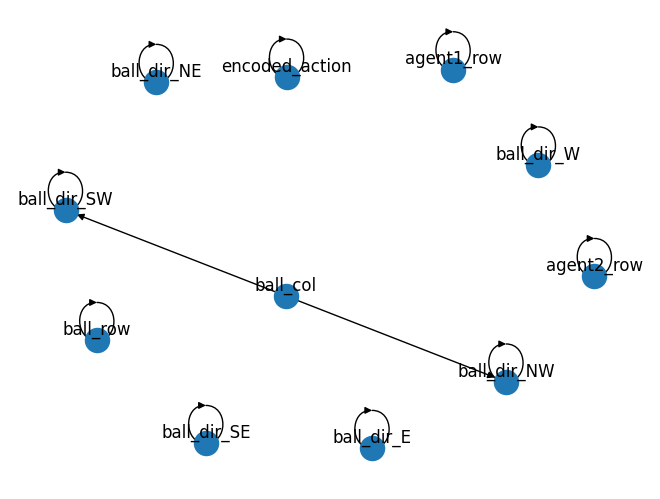

In [6]:
step = 500
# tuple of states, actions, rewards, states_new
states, actions, rewards, states_new = xrl.replay_buffer

from cxrl.lib.utils import convert_and_expand
states = convert_and_expand(states).astype(float)
actions = convert_and_expand(actions).astype(float)

replay = pd.DataFrame(np.concatenate((states, actions), axis=1), columns=feature_names)

query = replay[step:step+1]
localG = xrl.local_causal_network(query)
xrl.render_network(localG)